###### Matplotlib — 15 Visualization Questions
###### 1. Monthly Revenue Line Chart
###### Using order_date and revenue:
###### • Convert order_date to datetime.
###### • Calculate total revenue for each month.
###### • Create a line chart.
###### • Add:
###### o Title
###### o X-axis label
###### o Y-axis label
###### o Grid
###### o Markers
###### Commands/concepts: plt.plot(), plt.title(), plt.xlabel(), plt.ylabel(), plt.grid()

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
df=pd.read_csv("C:\\Users\\hp\\Downloads\\cleaned_data_matplotlib_messy_sales_2000 (2).xls")
df["city"].value_counts()

city
Banglore     384
Mumbai       347
Hyderabad    332
Delhi        331
Pune         298
Chennai      297
hyderbad       5
Name: count, dtype: int64

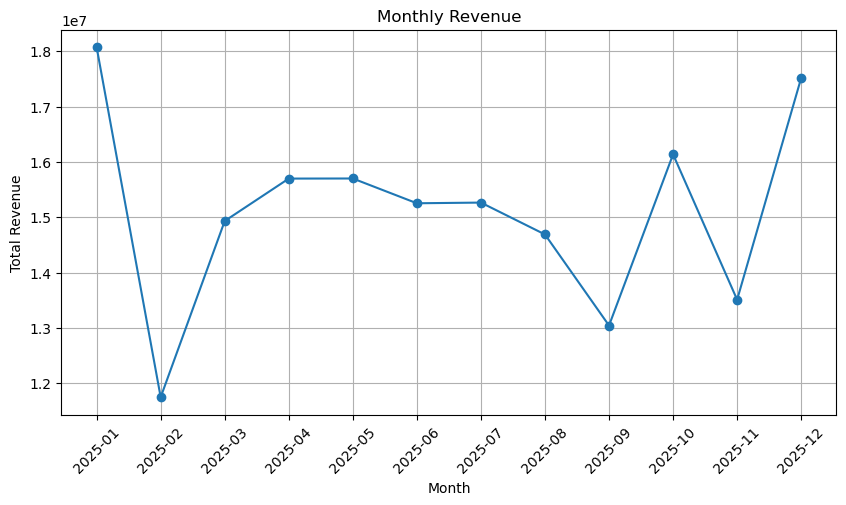

In [2]:
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")

# 2. Calculate monthly revenue
monthly_revenue = df.groupby(df["order_date"].dt.to_period("M"))["revenue"].sum()
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))


plt.plot(monthly_revenue.index.astype(str),monthly_revenue.values,marker="o")
plt.tick_params(axis="x",rotation=45)
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Total Revenue")

# 5. Add grid
plt.grid(True)



# 6. Show chart
plt.show()

##### 2. Monthly Profit Line Chart
##### Create a line chart showing monthly Profit.
##### Requirements:
##### • Use a different line style.
##### • Add markers.
##### • Add a legend.
##### • Display the value of the highest-profit month using annotate().
##### Commands/concepts: plt.plot(), plt.legend(), plt.annotate()

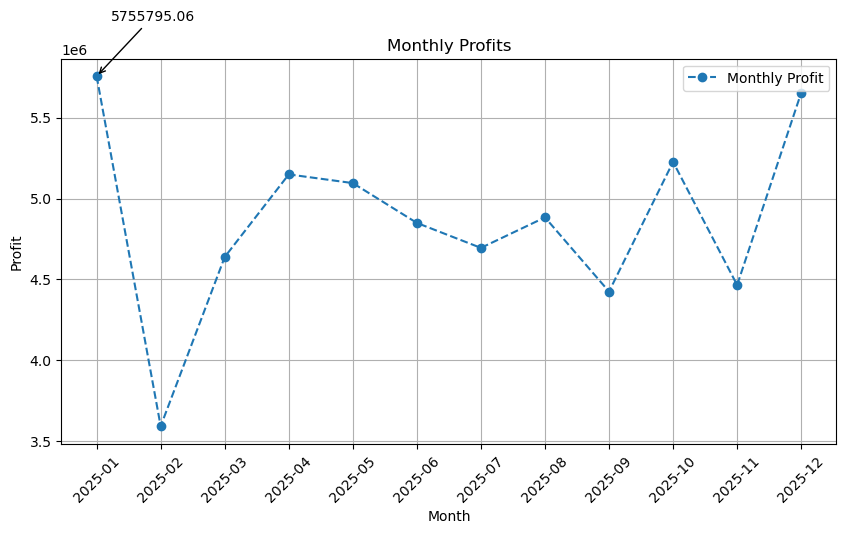

In [5]:
df["order_date"]=pd.to_datetime(df["order_date"],errors="coerce")
monthly_profit=df.groupby(df["order_date"].dt.to_period("M"))["profit"].sum()
highest_profit_month=monthly_profit.idxmax()
highest_profit=monthly_profit.max()
plt.figure(figsize=(10, 5))
plt.plot(monthly_profit.index.astype(str),monthly_profit.values,linestyle="--",marker="o",label="Monthly Profit")
plt.tick_params(axis="x",rotation=45)

plt.title("Monthly Profits")
plt.xlabel("Month")
plt.ylabel("Profit")
plt.legend()
plt.annotate(highest_profit,xy=(str(highest_profit_month),highest_profit),xytext=(10, 40),textcoords="offset points",arrowprops=dict(arrowstyle="->"))
plt.grid(True)

plt.show()

###### 3. Revenue by Product Category — Bar Chart
###### Calculate total revenue for each product_category.
###### Create a bar chart.
###### Requirements:
###### • X-axis → Product Category
###### • Y-axis → Revenue
###### • Add title and labels.
###### • Display the revenue value above each bar.
###### Commands/concepts: plt.bar(), plt.text()

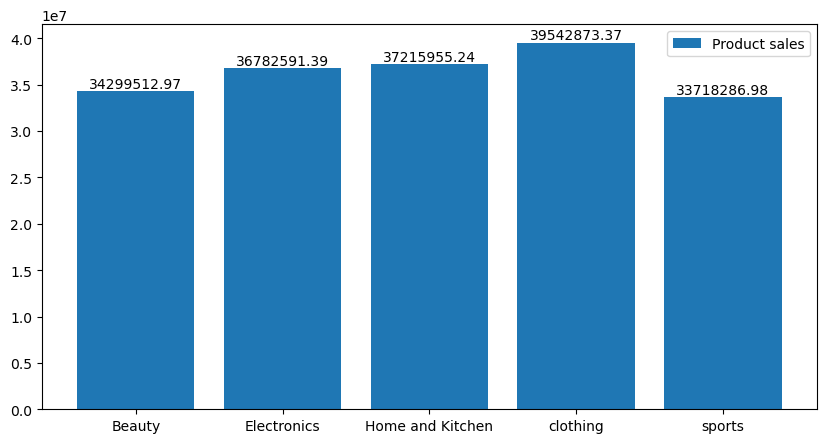

In [6]:
plt.figure(figsize=(10, 5))

total_revenue=df.groupby(df["product_category"])["revenue"].sum()
bars=plt.bar(total_revenue.index.astype(str),total_revenue.values,label="Product sales")
plt.xlabel="Product Category"
plt.ylabel="Rvenue"
plt.title="Sales Analsis"
plt.legend()
# Display revenue value above each bar
for bar in bars:
    value = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )
plt.show()

###### 4. Profit by City — Horizontal Bar Chart
###### Calculate total profit for each city.
###### Create a horizontal bar chart.
###### Requirements:
###### • Sort cities by profit.
###### • Show the highest-profit city first.
###### • Add title and axis labels.
###### Commands/concepts: plt.barh(), sort_values()

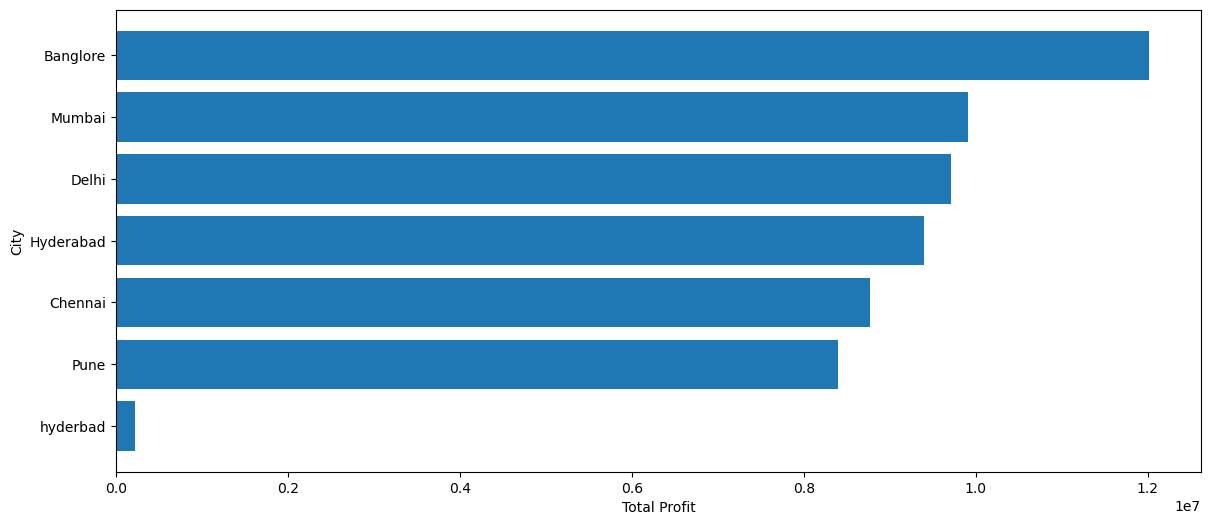

In [3]:
total_profit = df.groupby("city")["profit"].sum()
total_profit = total_profit.sort_values(ascending=False)


plt.figure(figsize=(14, 6))

plt.barh(total_profit.index, total_profit.values)


plt.xlabel("Total Profit")
plt.ylabel("City")

plt.gca().invert_yaxis()

plt.show()

###### 5. Customer Age Histogram
###### Create a histogram of the age column.
###### Requirements:
###### • Use 10 bins.
###### • Add title.
###### • Add X/Y labels.
###### • Add grid.
###### • Add a vertical line showing the median age.
###### Commands/concepts: plt.hist(), plt.axvline()

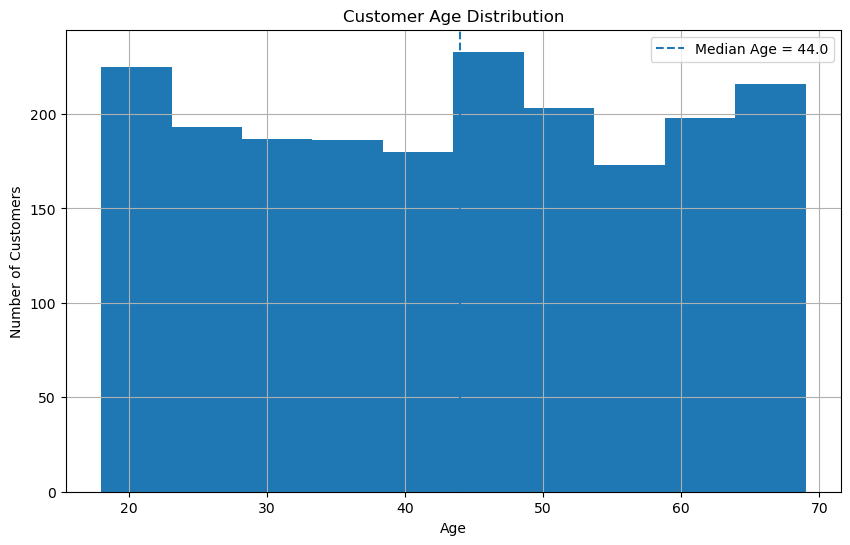

In [4]:
plt.figure(figsize=(10, 6))

plt.hist(df["age"].dropna(),bins=10)
age_median=df["age"].median()
plt.axvline(age_median,linestyle="--",
    label=f"Median Age = {age_median:.1f}")
plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
# Grid
plt.grid(True)

# Legend
plt.legend()

plt.show()

###### 6. Revenue Distribution Histogram
###### Create a histogram showing the distribution of revenue.
###### Requirements:
###### • Use 20 bins.
###### • Add transparency using alpha.
###### • Add grid.
###### • Add mean and median lines.
###### • Add a legend.
###### Commands/concepts:
###### plt.hist()
###### plt.axvline()
###### plt.legend()

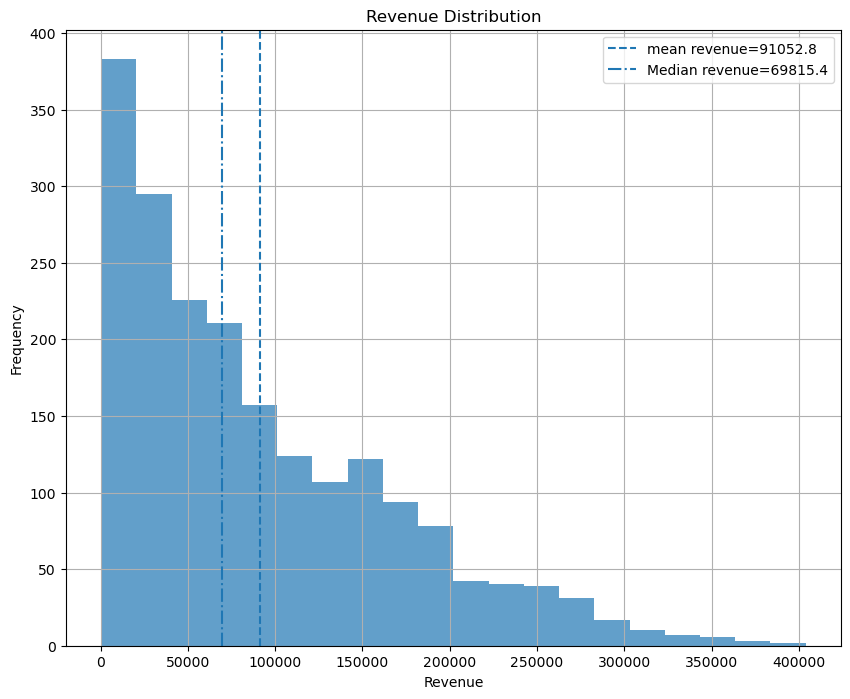

In [7]:
plt.figure(figsize=(10,8))
plt.hist(df["revenue"].dropna(),bins=20,alpha=0.7)
mean_revenue=df["revenue"].mean()
median_revenue=df["revenue"].median()
plt.axvline(mean_revenue,ls="--",label=f"mean revenue={mean_revenue:.1f}")
plt.axvline(median_revenue,ls="-.",label=f"Median revenue={median_revenue:.1f}")
plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")

# Grid
plt.grid(True)

# Legend
plt.legend()

plt.show()

###### 7. Revenue vs Profit Scatter Plot
###### Create a scatter plot between:
###### • X → Revenue
###### • Y → Profit
###### Requirements:
###### • Use different marker size.
###### • Add transparency.
###### • Add title and axis labels.
###### • Add grid.
###### Commands/concepts:
###### plt.scatter()
###### Important parameters to practice:
###### s=
###### alpha=
###### marker=

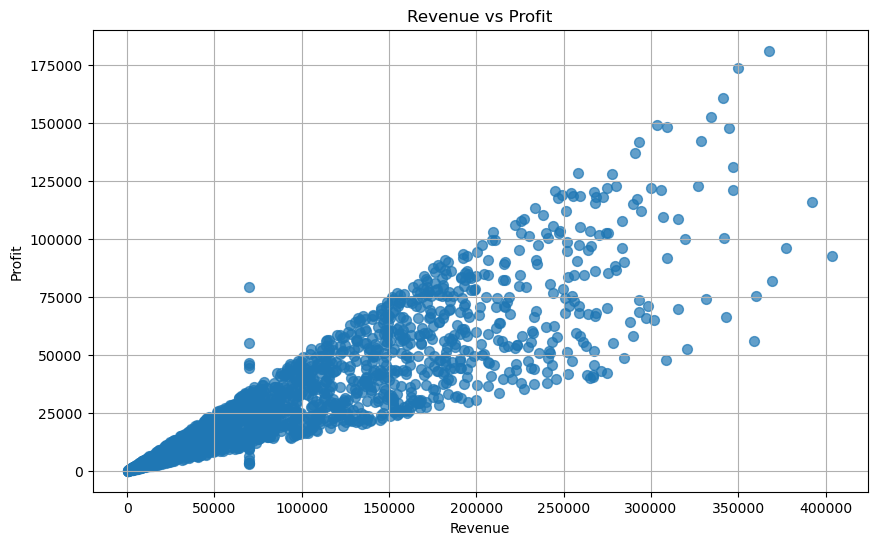

In [11]:
plt.figure(figsize=(10, 6))
plt.scatter(df["revenue"],df["profit"],s=50,alpha=0.7,marker="o")
plt.title("Revenue vs Profit")
plt.xlabel("Revenue")
plt.ylabel("Profit")

plt.grid(True)

plt.show()

###### 8. Discount vs Profit Scatter Plot
###### Create a scatter plot between:
###### • X → discount_pct
###### • Y → profit
###### Requirements:
###### • Use a different marker.
###### • Add transparency.
###### • Add title.
###### • Add axis labels.
###### • Add grid.
###### Then answer:
###### Does profit appear to decrease as discount increases?

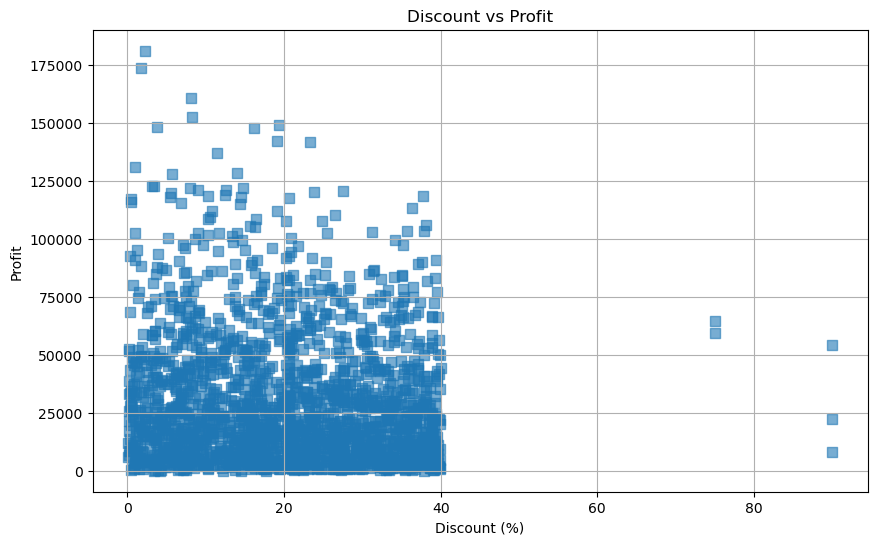

In [12]:

plt.figure(figsize=(10, 6))

plt.scatter(
    df["discount_pct"],
    df["profit"],
    s=50,
    alpha=0.6,
    marker="s"
)

plt.title("Discount vs Profit")
plt.xlabel("Discount (%)")
plt.ylabel("Profit")

plt.grid(True)

plt.show()

###### 9. Revenue Share — Pie Chart
###### Calculate total revenue for every product_category.
###### Create a pie chart showing each category's contribution.
###### Requirements:
###### • Display percentages.
###### • Display category names.
###### • Add a title.
###### • Start the first slice from the top.
###### Commands/concepts:
###### plt.pie()
###### Important parameters:
###### autopct=
###### startangle=
###### labels=

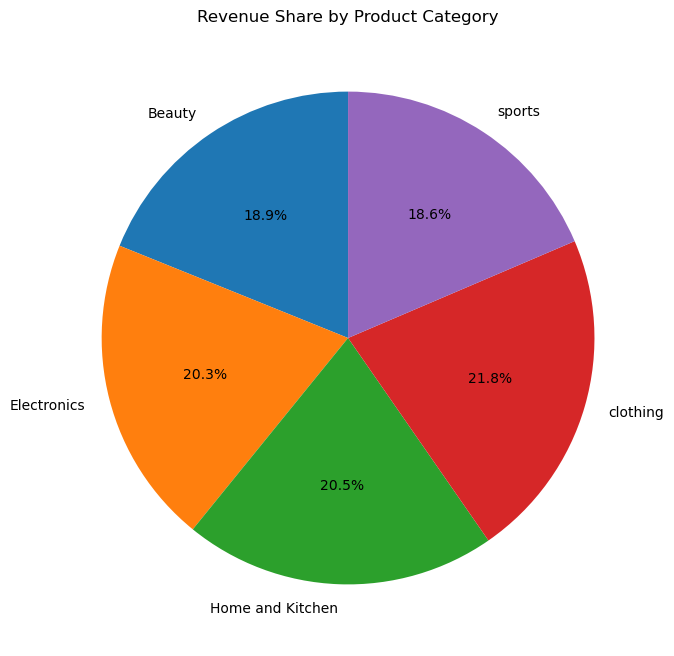

In [15]:
total_revenue=df.groupby("product_category")["revenue"].sum()
plt.figure(figsize=(8, 8))

plt.pie(total_revenue.values,labels=total_revenue.index.astype(str),autopct="%1.1f%%",startangle=90)
plt.title("Revenue Share by Product Category")

plt.show()

###### 10. Customer Segment Pie Chart
###### Create a pie chart showing the number of customers/orders in each customer segment.
###### Segments:
###### • Premium
###### • Regular
###### • Budget
###### Requirements:
###### • Show percentage.
###### • Add labels.
###### • Add title.
###### • Make the chart visually clean.
###### Question: Which customer segment has the largest share?

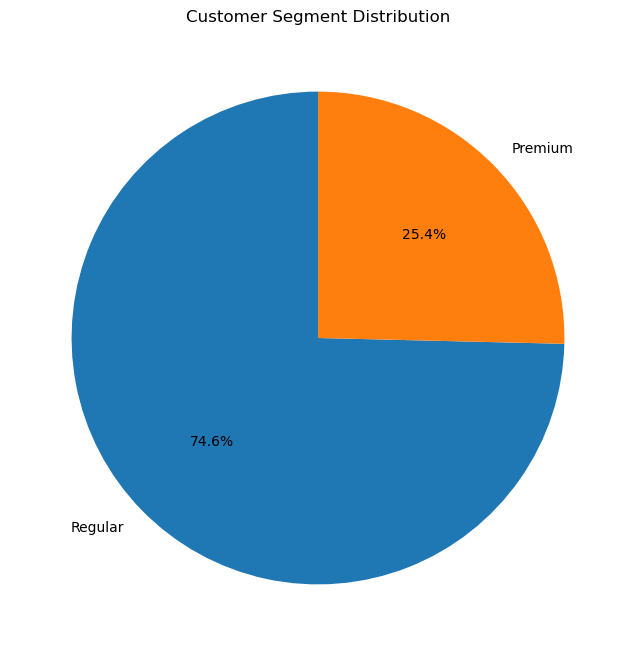

In [16]:
segment_count = df["customer_segment"].value_counts()
plt.figure(figsize=(8,8))
plt.pie(segment_count.values,labels=segment_count.index,autopct="%1.1f%%",startangle=90)
plt.title("Customer Segment Distribution")
plt.show()

###### 11. Compare Revenue and Profit
###### Create a grouped bar chart for each product_category.
###### For every category show:
###### • Revenue
###### • Profit
###### Requirements:
###### • Two bars per category.
###### • Different colors.
###### • Add legend.
###### • Add title and axis labels.
###### Concepts: plt.bar(), bar positions, width, plt.xticks()

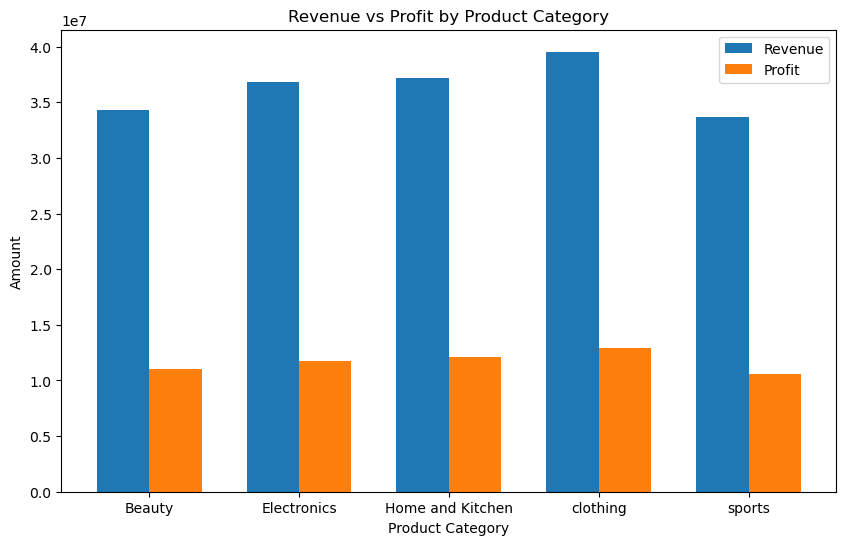

In [23]:
import numpy as np

category_data = df.groupby("product_category")[["revenue", "profit"]].sum()

# Create positions
x = np.arange(len(category_data))

# Bar width
width = 0.35

# Create figure
plt.figure(figsize=(10, 6))

# Revenue bars
plt.bar(
    x - width / 2,
    category_data["revenue"],
    width,
    label="Revenue"
)

# Profit bars
plt.bar(
    x + width / 2,
    category_data["profit"],
    width,
    label="Profit"
)

# Category names on X-axis
plt.xticks(x, category_data.index)

# Title and labels
plt.title("Revenue vs Profit by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Amount")

# Legend
plt.legend()

plt.show()

###### 12. Monthly Revenue vs Profit
###### Create a chart containing two lines:
###### • Revenue
###### • Profit
###### for every month.
###### Requirements:
###### • Different colors.
###### • Different markers.
###### • Different line styles.
###### • Legend.
###### • Grid.
###### • Title.
###### • X/Y labels.
###### Example concept:
###### plt.plot(months, revenue)
###### plt.plot(months, profit)

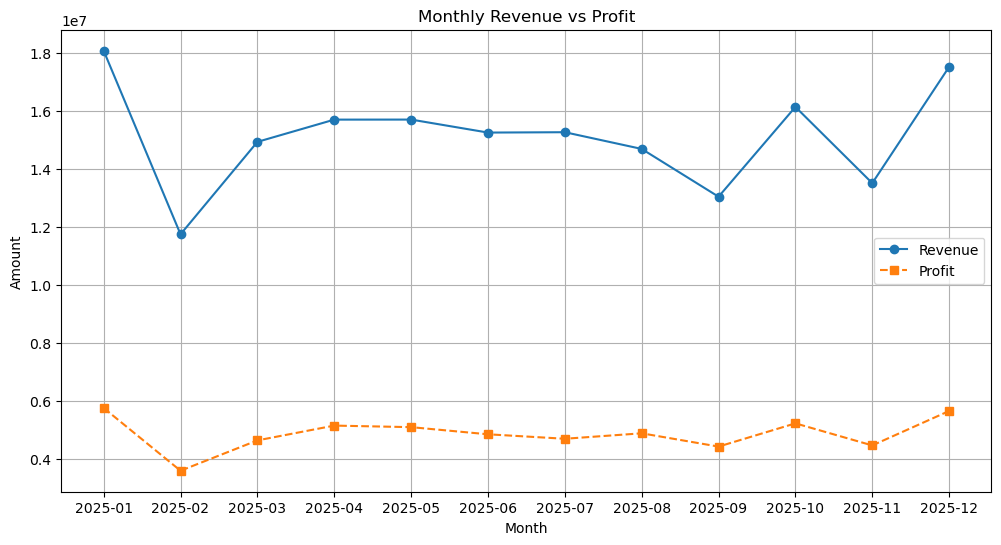

In [27]:
# Convert order_date to datetime
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")

# Calculate monthly revenue and profit
monthly_data = df.groupby(
    df["order_date"].dt.to_period("M")
)[["revenue", "profit"]].sum()
months = monthly_data.index.astype(str)

# Create chart
plt.figure(figsize=(12, 6))
plt.plot(months,monthly_data["revenue"],marker="o",ls="-",label="Revenue")
plt.plot(months,monthly_data["profit"],marker="s",linestyle="--",label="Profit")

# Title and labels
plt.title("Monthly Revenue vs Profit")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.legend()
plt.grid(True)

plt.show()

###### 13. Sales Channel Comparison
###### Calculate total revenue for:
###### • Online
###### • Retail
###### • Corporate
###### Create a bar chart.
###### Requirements:
###### • Add value labels on bars.
###### • Sort from highest to lowest.
###### • Add title.
###### • Add axis labels.
###### • Add grid.
###### Question: Which sales channel generates the highest revenue?

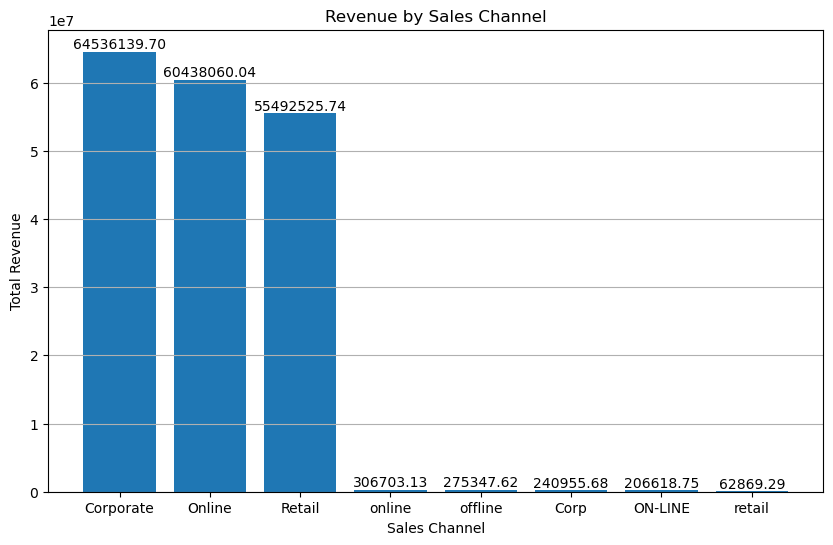

In [30]:
# Calculate total revenue by sales channel
channel_revenue = df.groupby("sales_channel")["revenue"].sum()

# Sort highest to lowest
channel_revenue = channel_revenue.sort_values(ascending=False)

# Create bar chart
plt.figure(figsize=(10, 6))

bars = plt.bar(
    channel_revenue.index,
    channel_revenue.values
)

# Add value labels above bars
for bar in bars:
    value = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )

# Title and labels
plt.title("Revenue by Sales Channel")
plt.xlabel("Sales Channel")
plt.ylabel("Total Revenue")

# Grid
plt.grid(axis="y")

plt.show()

###### 14. Four-Chart Matplotlib Dashboard
###### Create a 2 × 2 subplot.
###### Chart 1
###### Monthly Revenue → Line chart
###### Chart 2
###### Revenue by Category → Bar chart
###### Chart 3
###### Customer Age → Histogram
###### Chart 4
###### Revenue vs Profit → Scatter plot
###### Use:
###### plt.subplots(2, 2)
###### Give every subplot:
###### • Its own title
###### • Appropriate labels
###### • Grid where useful
###### Finally use:
###### plt.tight_layout()

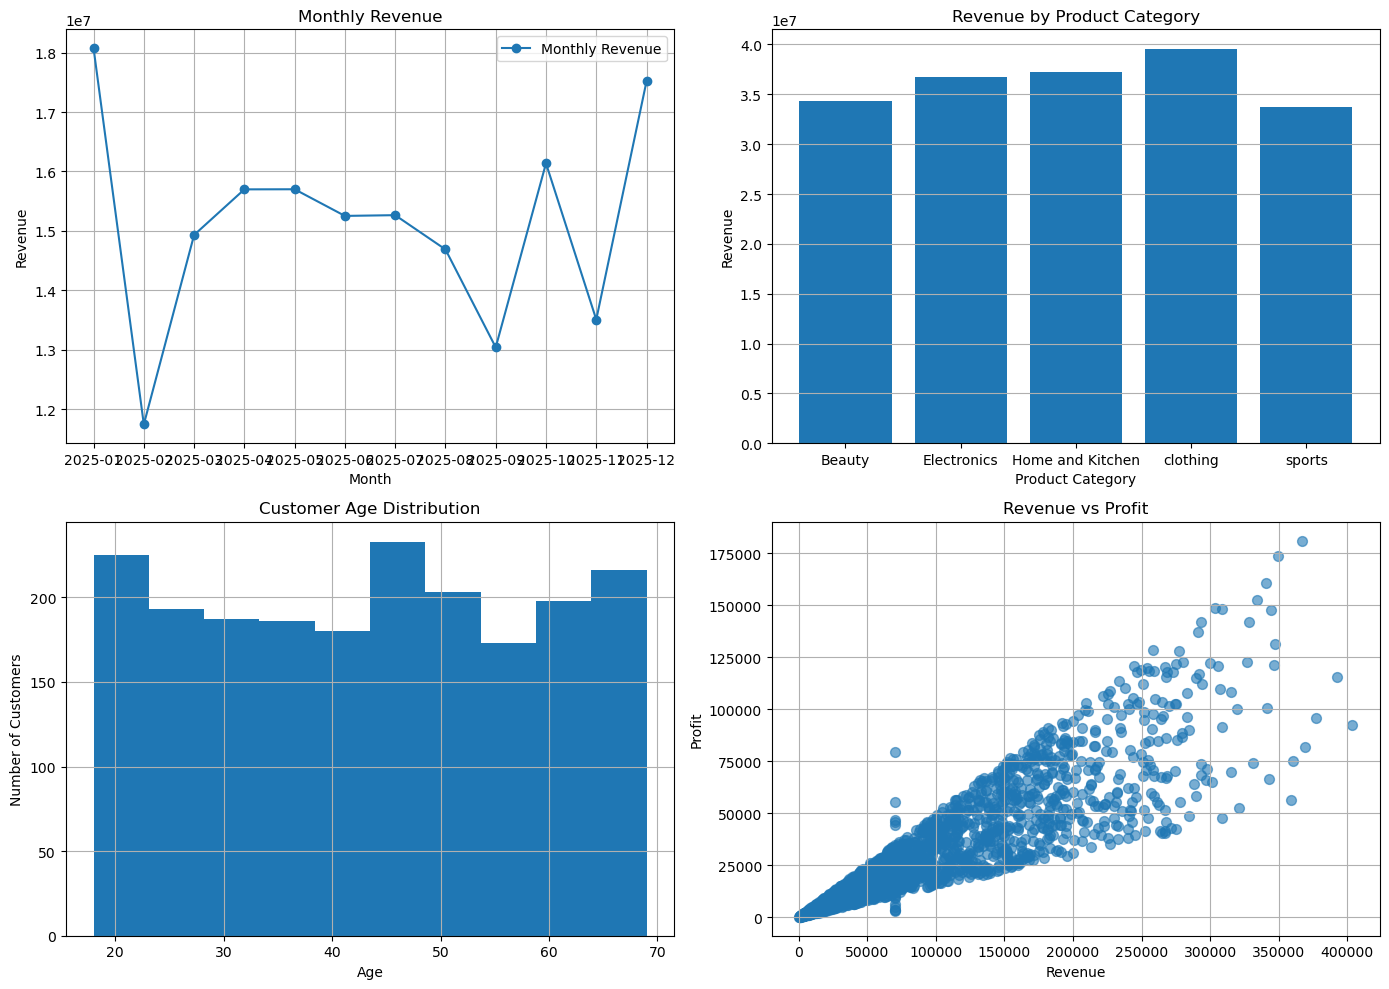

In [32]:
# Convert order_date to datetime
df["order_date"] = pd.to_datetime(
    df["order_date"],
    errors="coerce"
)

# Create 2 × 2 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))


# ==========================================
# Chart 1: Monthly Revenue - Line Chart
# ==========================================

monthly_revenue = df.groupby(
    df["order_date"].dt.to_period("M")
)["revenue"].sum()

axes[0, 0].plot(
    monthly_revenue.index.astype(str),
    monthly_revenue.values,
    marker="o",
    label="Monthly Revenue"
)

axes[0, 0].set_title("Monthly Revenue")
axes[0, 0].set_xlabel("Month")
axes[0, 0].set_ylabel("Revenue")
axes[0, 0].legend()
axes[0, 0].grid(True)


# ==========================================
# Chart 2: Revenue by Category - Bar Chart
# ==========================================

category_revenue = df.groupby(
    "product_category"
)["revenue"].sum()

axes[0, 1].bar(
    category_revenue.index,
    category_revenue.values
)

axes[0, 1].set_title("Revenue by Product Category")
axes[0, 1].set_xlabel("Product Category")
axes[0, 1].set_ylabel("Revenue")
axes[0, 1].grid(axis="y")


# ==========================================
# Chart 3: Customer Age - Histogram
# ==========================================

axes[1, 0].hist(
    df["age"].dropna(),
    bins=10
)

axes[1, 0].set_title("Customer Age Distribution")
axes[1, 0].set_xlabel("Age")
axes[1, 0].set_ylabel("Number of Customers")
axes[1, 0].grid(True)


# ==========================================
# Chart 4: Revenue vs Profit - Scatter Plot
# ==========================================

axes[1, 1].scatter(
    df["revenue"],
    df["profit"],
    s=50,
    alpha=0.6,
    marker="o"
)

axes[1, 1].set_title("Revenue vs Profit")
axes[1, 1].set_xlabel("Revenue")
axes[1, 1].set_ylabel("Profit")
axes[1, 1].grid(True)


# Adjust spacing
plt.tight_layout()

# Display dashboard
plt.show()

###### 15. Final Exam Question — Sales Analysis
###### Using the complete dataset, create a professional Matplotlib visualization containing:
###### Chart 1: Monthly Revenue → Line chart
###### Chart 2: Category Revenue → Bar chart
###### Chart 3: Revenue Distribution → Histogram
###### Chart 4: Revenue vs Profit → Scatter plot
###### Chart 5: Category Revenue Share → Pie chart
###### For the visual design:
###### • Add appropriate colors
###### • Use markers where appropriate
###### • Add legends
###### • Add grid
###### • Add titles
###### • Add X/Y labels
###### • Use alpha for transparency where appropriate
###### • Add value labels to bars
###### • Add percentage labels to pie chart
###### • Use figsize
###### • Use tight_layout()
###### Commands you should practice
###### plt.figure()
###### plt.plot()
###### plt.bar()
###### plt.barh()
###### plt.hist()
###### plt.scatter()
###### plt.pie()
###### plt.xlabel()
###### plt.ylabel()
###### plt.title()
###### plt.legend()
###### plt.grid()
###### plt.xticks()
###### plt.yticks()
###### plt.text()
###### plt.annotate()
###### plt.axvline()
###### plt.subplots()
###### plt.tight_layout()
###### plt.show()

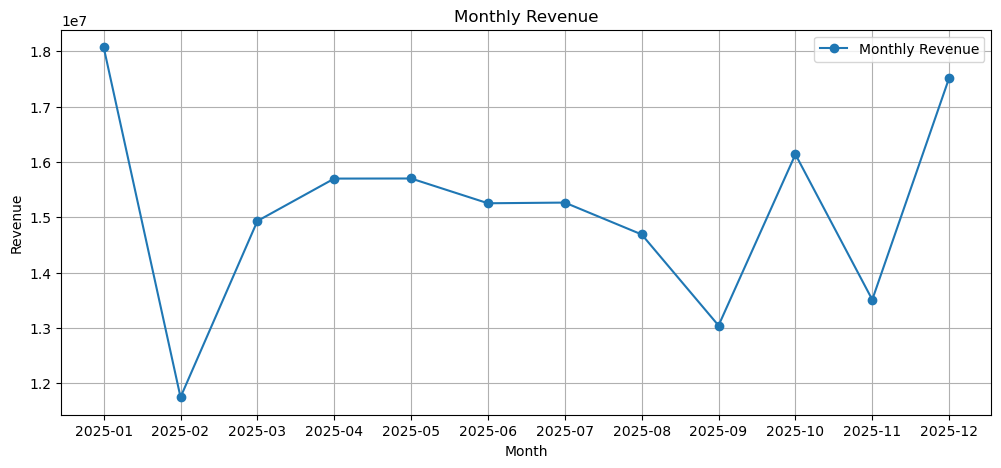

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert order_date into datetime
df["order_date"] = pd.to_datetime(
    df["order_date"],
    errors="coerce"
)


# =========================================================
# 1. MONTHLY REVENUE - LINE CHART
# =========================================================

monthly_revenue = df.groupby(
    df["order_date"].dt.to_period("M")
)["revenue"].sum()

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_revenue.index.astype(str),
    monthly_revenue.values,
    marker="o",
    linestyle="-",
    label="Monthly Revenue"
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.legend()
plt.grid(True)

plt.show()


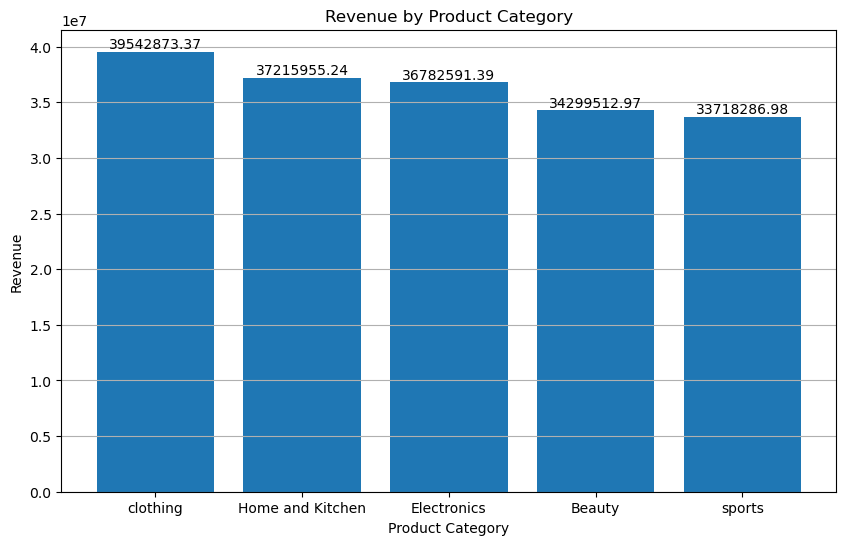

In [39]:
# =========================================================
# 2. CATEGORY REVENUE - BAR CHART
# =========================================================

category_revenue = df.groupby(
    "product_category"
)["revenue"].sum()

category_revenue = category_revenue.sort_values(
    ascending=False
)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    category_revenue.index,
    category_revenue.values
)

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")

plt.grid(axis="y")

# Add values above bars
for bar in bars:
    value = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )

plt.show()


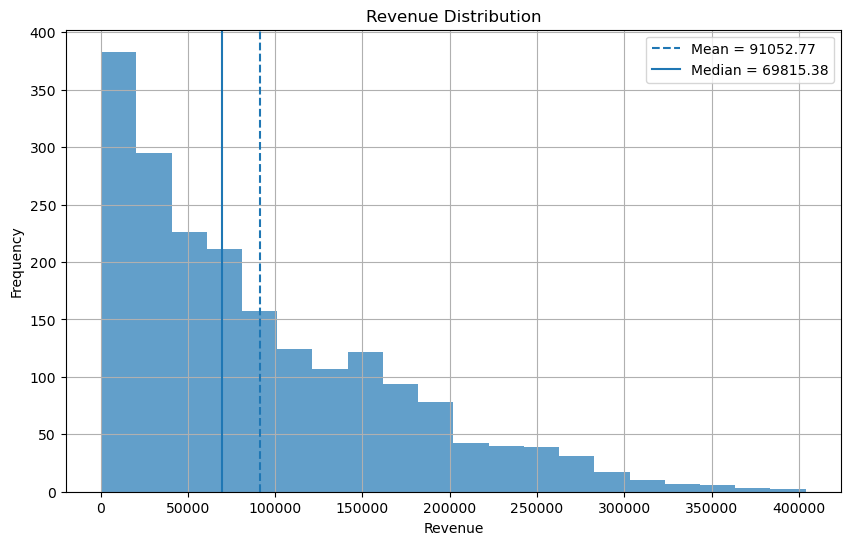

In [40]:
# =========================================================
# 3. REVENUE DISTRIBUTION - HISTOGRAM
# =========================================================

mean_revenue = df["revenue"].mean()
median_revenue = df["revenue"].median()

plt.figure(figsize=(10, 6))

plt.hist(
    df["revenue"].dropna(),
    bins=20,
    alpha=0.7
)

# Mean line
plt.axvline(
    mean_revenue,
    linestyle="--",
    label=f"Mean = {mean_revenue:.2f}"
)

# Median line
plt.axvline(
    median_revenue,
    linestyle="-",
    label=f"Median = {median_revenue:.2f}"
)

plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")

plt.legend()
plt.grid(True)

plt.show()

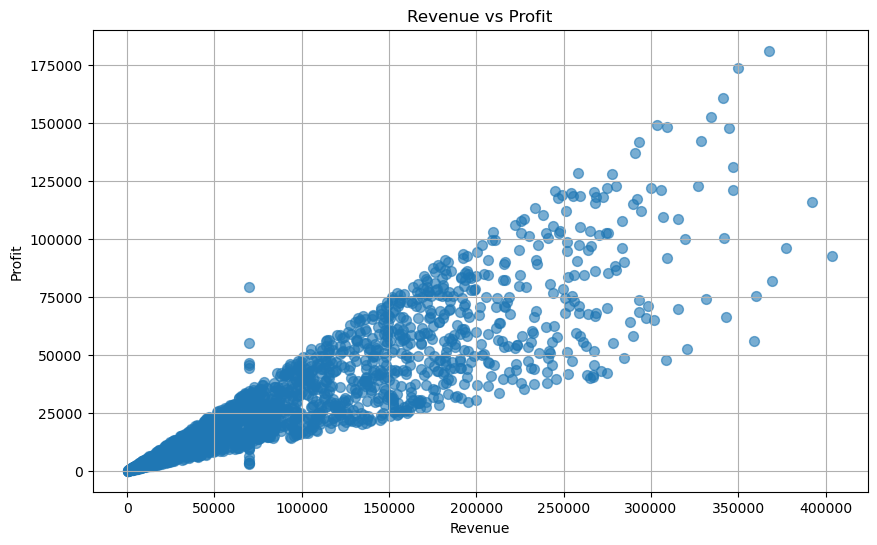

In [41]:

# =========================================================
# 4. REVENUE VS PROFIT - SCATTER PLOT
# =========================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    df["revenue"],
    df["profit"],
    s=50,
    alpha=0.6,
    marker="o"
)

plt.title("Revenue vs Profit")
plt.xlabel("Revenue")
plt.ylabel("Profit")

plt.grid(True)

plt.show()

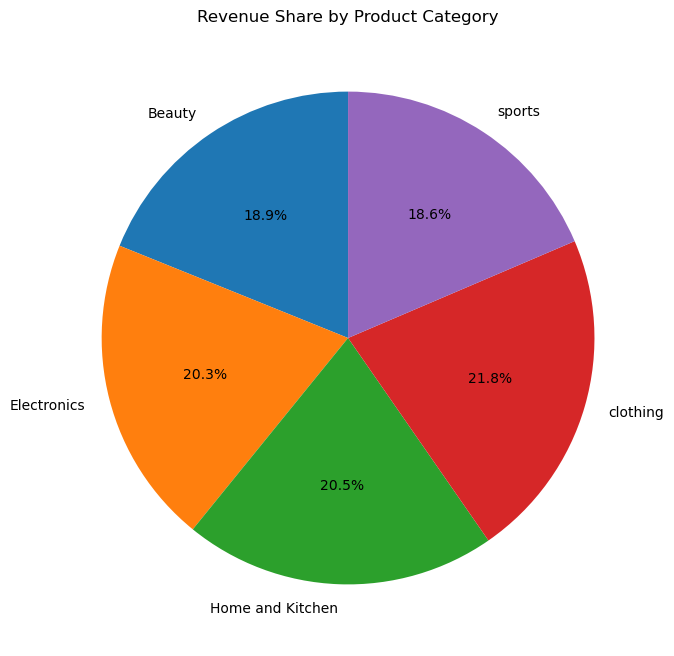

In [42]:
# =========================================================
# 5. CATEGORY REVENUE SHARE - PIE CHART
# =========================================================

category_revenue = df.groupby(
    "product_category"
)["revenue"].sum()

plt.figure(figsize=(8, 8))

plt.pie(
    category_revenue.values,
    labels=category_revenue.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Revenue Share by Product Category")

plt.show()